# 01 DATA CLEANING

Este notebook realiza o processo de data cleaning do dataset da competição Give Me Some Credit, incluindo tratamento de valores ausentes, detecção e correção de outliers, validação de consistência e preparação inicial dos dados para as próximas etapas do pipeline.

| Variável | Descrição 
|----------|----------
| **SeriousDlqin2yrs** | Indica inadimplência grave em até 2 anos (1 = sim, 0 = não) 
| **age** | Idade do cliente 
| **RevolvingUtilizationOfUnsecuredLines** | Percentual de uso do crédito rotativo 
| **NumberOfTime30-59DaysPastDueNotWorse** | Nº de atrasos entre 30–59 dias 
| **NumberOfTime60-89DaysPastDueNotWorse** | Nº de atrasos entre 60–89 dias 
| **NumberOfTimes90DaysLate** | Nº de atrasos >90 dias 
| **MonthlyIncome** | Renda mensal 
| **DebtRatio** | Relação dívida/renda 
| **NumberOfOpenCreditLinesAndLoans** | Total de linhas de crédito abertas 
| **NumberRealEstateLoansOrLines** | Nº de empréstimos imobiliários 
| **NumberOfDependents** | Nº de dependentes 

### Visualização inicial dos dados e exploração das features disponíveis

In [1]:
# Importação das principais bibliotecas utilizadas
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import normaltest

# Configuração de visualização de colunas do jupyter
pd.set_option('display.max_columns', None) # mostrando todas as colunas na visualização dos dataframes
pd.set_option('display.float_format', lambda x: '%.2f' % x) # Adaptando visualização dos campos float

In [2]:
# Leitura dos dados de treino
df = pd.read_csv(r"../data/raw/cs-training.csv")

In [3]:
# Visualização das primeiras e últimas linhas
display(df)

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.77,45,2,0.80,9120.00,13,0,6,0,2.00
1,2,0,0.96,40,0,0.12,2600.00,4,0,0,0,1.00
2,3,0,0.66,38,1,0.09,3042.00,2,1,0,0,0.00
3,4,0,0.23,30,0,0.04,3300.00,5,0,0,0,0.00
4,5,0,0.91,49,1,0.02,63588.00,7,0,1,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...
149995,149996,0,0.04,74,0,0.23,2100.00,4,0,1,0,0.00
149996,149997,0,0.30,44,0,0.72,5584.00,4,0,1,0,2.00
149997,149998,0,0.25,58,0,3870.00,NaN,18,0,1,0,0.00
149998,149999,0,0.00,30,0,0.00,5716.00,4,0,0,0,0.00


Pelo que podemos perceber, a coluna "Unnamed: 0" aparenta ser do tipo "id", não sendo uma informação relevante para nosso objeto de estudo. Por essa razão, irei excluí-la do dataframe

In [4]:
# Excluindo a coluna até o momento não relevante do dataframe
df.drop(columns='Unnamed: 0', inplace=True)

Tendo em vista que podemos trabalhar realizando diversas operações com o nome das colunas do dataframe, entendo que renomeá-las sem perder o sentido vai trazer ganhos de produtividade para as ações futuras.

In [5]:
# Renomeando as colunas para facilitar processo de desenvolvimento sem perder informações
column_mapping = {
    "SeriousDlqin2yrs": "target_default_2y",
    "age": "age",
    "RevolvingUtilizationOfUnsecuredLines": "revolving_utilization",
    "NumberOfTime30-59DaysPastDueNotWorse": "late_30_59_days",
    "NumberOfTime60-89DaysPastDueNotWorse": "late_60_89_days",
    "NumberOfTimes90DaysLate": "late_90_plus_days",
    "MonthlyIncome": "monthly_income",
    "DebtRatio": "debt_ratio",
    "NumberOfOpenCreditLinesAndLoans": "num_credit_lines",
    "NumberRealEstateLoansOrLines": "num_real_estate_loans",
    "NumberOfDependents": "num_dependents"
}

df_renamed = df.rename(columns=column_mapping)

# Remoção do dataframe original para reduzir consumo de memória RAM
del df

In [6]:
# Verificando as primeiras linhas
df_renamed.head()

,target_default_2y,revolving_utilization,age,late_30_59_days,debt_ratio,monthly_income,num_credit_lines,late_90_plus_days,num_real_estate_loans,late_60_89_days,num_dependents
0,1,0.77,45,2,0.80,9120.00,13,0,6,0,2.00
1,0,0.96,40,0,0.12,2600.00,4,0,0,0,1.00
2,0,0.66,38,1,0.09,3042.00,2,1,0,0,0.00
3,0,0.23,30,0,0.04,3300.00,5,0,0,0,0.00
4,0,0.91,49,1,0.02,63588.00,7,0,1,0,0.00


In [7]:
# organizando a ordem das colunas para facilitar análise e fluxo de tratamento
df_renamed = df_renamed[[
    'target_default_2y',
    'revolving_utilization',
    'age',
    'debt_ratio',
    'monthly_income',
    'num_credit_lines',
    'late_30_59_days',
    'late_60_89_days',
    'late_90_plus_days',
    'num_real_estate_loans',
    'num_dependents'
]]

df_renamed.head()

,target_default_2y,revolving_utilization,age,debt_ratio,monthly_income,num_credit_lines,late_30_59_days,late_60_89_days,late_90_plus_days,num_real_estate_loans,num_dependents
0,1,0.77,45,0.80,9120.00,13,2,0,0,6,2.00
1,0,0.96,40,0.12,2600.00,4,0,0,0,0,1.00
2,0,0.66,38,0.09,3042.00,2,1,0,1,0,0.00
3,0,0.23,30,0.04,3300.00,5,0,0,0,0,0.00
4,0,0.91,49,0.02,63588.00,7,1,0,0,1,0.00


### Análise de tipagem e valores ausentes

In [8]:
df_renamed.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   target_default_2y      150000 non-null  int64  
 1   revolving_utilization  150000 non-null  float64
 2   age                    150000 non-null  int64  
 3   debt_ratio             150000 non-null  float64
 4   monthly_income         120269 non-null  float64
 5   num_credit_lines       150000 non-null  int64  
 6   late_30_59_days        150000 non-null  int64  
 7   late_60_89_days        150000 non-null  int64  
 8   late_90_plus_days      150000 non-null  int64  
 9   num_real_estate_loans  150000 non-null  int64  
 10  num_dependents         146076 non-null  float64
dtypes: float64(4), int64(7)
memory usage: 12.6 MB


O dataset apresenta 150k linhas, sendo os campos "monthly_income" e "num_dependents" com dados ausentes que precisam da nossa atenção.

#### Analisando a imputação para o campo 'monthly_income'

Nos casos de valores ausentes, é comum utilizarmos a média ou mediana para ocupar esses espaços. Como normalmente valores de rendas apresentam outliers e não apresentam comportamento da distribuição normal, faz mais sentido utilizarmos a mediana a fim de evitarmos ao máximo enviesar o projeto.

In [9]:
# Verificando a média
mean_monthly_income = df_renamed.monthly_income.mean()
print(mean_monthly_income)

6670.221237392844


In [10]:
# Verificando a mediana 
median_monthly_income = df_renamed.monthly_income.median()
print(median_monthly_income)

5400.0


Text(0.5, 1.0, 'Distribuição de Monthly Income')

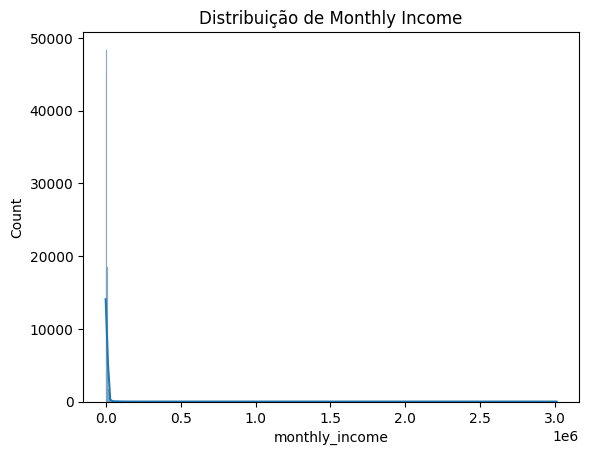

In [11]:
# Entendendo a distribuição dos dados de receita mensal
sns.histplot(df_renamed['monthly_income'].dropna(), kde=True)
plt.title("Distribuição de Monthly Income")

In [12]:
# Teste de normalidade
stat, p = normaltest(df_renamed['monthly_income'].dropna())

print(f"P-valor do teste de normalidade: {p:.6f}")

if p < 0.05:
    print("Interpretação: rejeitamos H0 — a distribuição NÃO é normal.")
else:
    print("Interpretação: não rejeitamos H0 — a distribuição pode ser considerada normal.")

P-valor do teste de normalidade: 0.000000
Interpretação: rejeitamos H0 — a distribuição NÃO é normal.


Após confirmarmos que de fato os dados da renda mensal não estão em uma distribuição normal, irei fazer o input da mediana para ocupar os valores ausentes.

In [13]:
# Inputando a mediana para os valores ausentes
df_renamed['monthly_income'] = df_renamed['monthly_income'].fillna(median_monthly_income)

print(f"Mediana utilizada para imputação: {median_monthly_income}")

Mediana utilizada para imputação: 5400.0


#### Analisando a imputação para o campo 'num_dependents'

In [14]:
# Verificando distribuição dos valores
df_renamed['num_dependents'].value_counts(normalize=True)

num_dependents
0.00    0.59
1.00    0.18
2.00    0.13
3.00    0.06
4.00    0.02
5.00    0.01
6.00    0.00
7.00    0.00
8.00    0.00
10.00   0.00
9.00    0.00
20.00   0.00
13.00   0.00
Name: proportion, dtype: float64

In [15]:
# Quantidade de registros com valor ausente
df_renamed['num_dependents'].isna().sum()

np.int64(3924)

In [16]:
# Estátisticas descritivas básicas:
df_renamed['num_dependents'].describe()

count   146076.00
mean         0.76
std          1.12
min          0.00
25%          0.00
50%          0.00
75%          1.00
max         20.00
Name: num_dependents, dtype: float64

A variável num_dependents é discreta e apresenta forte concentração em poucos valores (especialmente 0 e 1).
Como a moda representa o valor mais frequente e evita a criação de valores artificiais, a imputação pela moda é a abordagem mais adequada para esta variável.


In [17]:
# Identificando a moda e armazenando em variável
moda_dependents = df_renamed['num_dependents'].mode()[0]

# Inputação dos valores ausentes
df_renamed['num_dependents'] = df_renamed['num_dependents'].fillna(moda_dependents)

print(f"Moda utilizada para imputação: {moda_dependents}")

Moda utilizada para imputação: 0.0


### Verificação do dataset após as as imputações

In [18]:
df_renamed.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   target_default_2y      150000 non-null  int64  
 1   revolving_utilization  150000 non-null  float64
 2   age                    150000 non-null  int64  
 3   debt_ratio             150000 non-null  float64
 4   monthly_income         150000 non-null  float64
 5   num_credit_lines       150000 non-null  int64  
 6   late_30_59_days        150000 non-null  int64  
 7   late_60_89_days        150000 non-null  int64  
 8   late_90_plus_days      150000 non-null  int64  
 9   num_real_estate_loans  150000 non-null  int64  
 10  num_dependents         150000 non-null  float64
dtypes: float64(4), int64(7)
memory usage: 12.6 MB


### Análise de valores impossíveis

##### Verificação da existência de valores negativos

In [19]:
# Filtrando linhas onde qualquer coluna tem valor menor que zero
df_com_negativos = df_renamed[(df_renamed < 0).any(axis=1)]; df_com_negativos

,target_default_2y,revolving_utilization,age,debt_ratio,monthly_income,num_credit_lines,late_30_59_days,late_60_89_days,late_90_plus_days,num_real_estate_loans,num_dependents


Desta forma, constatamos que não há valores negativos no conjunto de dados

------

In [20]:
# Visualização das estatísticas básicas dos campos
df_renamed.describe()

,target_default_2y,revolving_utilization,age,debt_ratio,monthly_income,num_credit_lines,late_30_59_days,late_60_89_days,late_90_plus_days,num_real_estate_loans,num_dependents
count,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00
mean,0.07,6.05,52.30,353.01,6418.45,8.45,0.42,0.24,0.27,1.02,0.74
std,0.25,249.76,14.77,2037.82,12890.40,5.15,4.19,4.16,4.17,1.13,1.11
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.03,41.00,0.18,3903.00,5.00,0.00,0.00,0.00,0.00,0.00
50%,0.00,0.15,52.00,0.37,5400.00,8.00,0.00,0.00,0.00,1.00,0.00
75%,0.00,0.56,63.00,0.87,7400.00,11.00,0.00,0.00,0.00,2.00,1.00
max,1.00,50708.00,109.00,329664.00,3008750.00,58.00,98.00,98.00,98.00,54.00,20.00


---------

##### Analisando o campo "revolving_utilization"

O campo "revolving_utilization" aponta para o percentual de utilização do limite de total de crédito.

Ou seja:

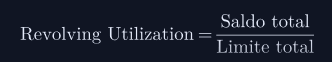

Podemos interpretar esse campo assim:

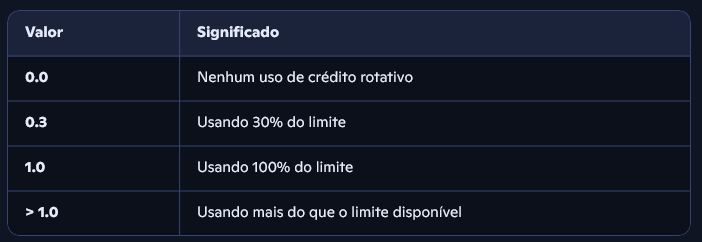

In [21]:
# Verificando o volume de registros com valor acima de 1.0:
df_renamed.query("revolving_utilization > 1.0").revolving_utilization.sort_values(ascending=False)

85489    50708.00
31414    29110.00
16956    22198.00
149160   22000.00
149279   20514.00
           ...   
96819        1.00
87196        1.00
27006        1.00
123305       1.00
114074       1.00
Name: revolving_utilization, Length: 3321, dtype: float64

Embora valores acima de 1.0 sejam teoricamente possíveis em situações de estouro de limite, os valores extremos presentes no dataset (como dezenas de milhares) são inconsistentes com o comportamento real de crédito rotativo.
Para evitar distorções e manter a coerência dos dados, aplicamos um limite superior de 1.0 (100%), que representa o uso total do limite disponível.


In [22]:
df_renamed['revolving_utilization'] = df_renamed['revolving_utilization'].clip(0.0, 1.0)
df_renamed.sort_values('revolving_utilization', ascending=False).head()

,target_default_2y,revolving_utilization,age,debt_ratio,monthly_income,num_credit_lines,late_30_59_days,late_60_89_days,late_90_plus_days,num_real_estate_loans,num_dependents
149973,0,1.00,44,0.49,5500.00,7,0,0,0,1,1.00
149939,0,1.00,26,0.07,6500.00,6,0,1,0,0,0.00
51576,0,1.00,33,0.06,31166.00,10,0,1,0,1,0.00
80157,0,1.00,44,0.01,2583.00,2,0,0,0,0,2.00
36651,0,1.00,48,0.31,8333.00,10,0,1,0,1,0.00


##### Analisando o campo "age"

In [23]:
df_renamed.age.describe()

count   150000.00
mean        52.30
std         14.77
min          0.00
25%         41.00
50%         52.00
75%         63.00
max        109.00
Name: age, dtype: float64

Podemos observar que a idade mínima no conjunto de dados é 0, o que não faz muito sentido para um cliente que possa desejar contrair um empréstimo bancário. Vamos analisar a quantidade de pessoas com essa idade e avaliar se iremos excluí-las do dataset. Uma observação interessante é que a distribuição das idades aparenta ter um comportamento de distribuição normal, tendo em vista a proximidade da média e mediana.

In [24]:
df_renamed.age.value_counts(normalize=False)

age
49     3837
48     3806
50     3753
47     3719
63     3719
       ... 
102       3
109       2
107       1
105       1
0         1
Name: count, Length: 86, dtype: int64

Conforme contagem das idades, só há um registro com 0 anos de idade. Vamos observar como esses dados estão distribuídos via histograma.

<Axes: >

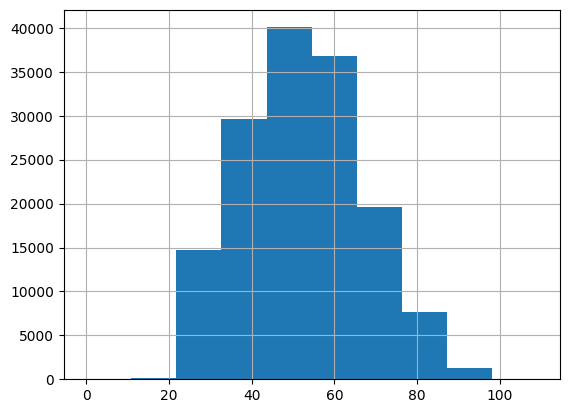

In [25]:
# Criando um histograma da variável "age"
df_renamed.age.hist()

A distribuição parece seguir uma distribuição normal, mas o ponto interessante é que as idades mínimas relevantes parecem começar aos 20 anos para o conjunto de dados, o que faz bastante sentido tendo em vista que normalmente as idades mínimas legais para contração de dívida ficam em torno dos 18 a 21 anos.

Vamos observar quantos registros temos nas faixas de idade até 24 anos

In [26]:
# Verificando a quantidade de registros por idade entre os mais jovens
df_renamed.query("age < 25").age.value_counts()

age
24    816
23    641
22    434
21    183
0       1
Name: count, dtype: int64

Após essa verificação, podemos identicar que a idade "0" representa um único registro que fica abaixo dos 21 anos. Por essa razão, excluirei esse dado da análise, tendo em vista que nossa intenção é identificar a probabilidade de inadimplência dos clientes. Para isso, o cliente precisa ter idade legal para poder contrair dívidas.

In [27]:
# Exlusão de registro com idade menor que 21 anos
df_renamed.query("age >= 21", inplace=True)

In [28]:
df_renamed

,target_default_2y,revolving_utilization,age,debt_ratio,monthly_income,num_credit_lines,late_30_59_days,late_60_89_days,late_90_plus_days,num_real_estate_loans,num_dependents
0,1,0.77,45,0.80,9120.00,13,2,0,0,6,2.00
1,0,0.96,40,0.12,2600.00,4,0,0,0,0,1.00
2,0,0.66,38,0.09,3042.00,2,1,0,1,0,0.00
3,0,0.23,30,0.04,3300.00,5,0,0,0,0,0.00
4,0,0.91,49,0.02,63588.00,7,1,0,0,1,0.00
...,...,...,...,...,...,...,...,...,...,...,...
149995,0,0.04,74,0.23,2100.00,4,0,0,0,1,0.00
149996,0,0.30,44,0.72,5584.00,4,0,0,0,1,2.00
149997,0,0.25,58,3870.00,5400.00,18,0,0,0,1,0.00
149998,0,0.00,30,0.00,5716.00,4,0,0,0,0,0.00


##### Analisando o campo "debt_ratio"

In [29]:
# Verificando a quantidade de registros que tem a relação entre dívida e renda acima de 100%
df_renamed.query("debt_ratio > 1.0").debt_ratio.count()

np.int64(35137)

O campo **debt_ratio** representa a proporção da renda mensal comprometida com dívidas.

Diferentemente de **revolving_utilization**, o campo **debt_ratio** não possui um limite natural de 100%.
Valores acima de 1.0 são plausíveis e representam situações reais de superendividamento.

Portanto, limitar o debt_ratio a 1.0 destruiria informação relevante.
Em vez disso, aplicamos um cap no percentil 99, que preserva valores plausíveis acima de 1.0 e remove apenas valores extremos e inconsistentes, garantindo integridade estatística e melhor desempenho do modelo.


In [30]:
percentil_debt_ratio_filtro = df_renamed['debt_ratio'].quantile(0.99)
df_renamed['debt_ratio'] = df_renamed['debt_ratio'].clip(0, percentil_debt_ratio_filtro)
print(f"Valor máximo após cap: {percentil_debt_ratio_filtro}")

Valor máximo após cap: 4979.079999999958


##### Analisando o campo "monthly_income"

count    149999.00
mean       6418.46
std       12890.44
min           0.00
25%        3903.00
50%        5400.00
75%        7400.00
max     3008750.00
Name: monthly_income, dtype: float64


<Axes: ylabel='monthly_income'>

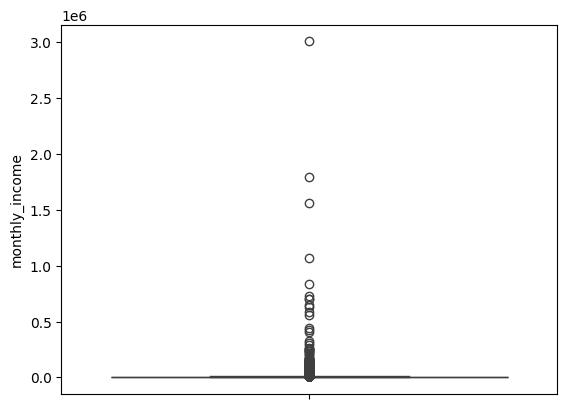

In [31]:
print(df_renamed['monthly_income'].describe())
sns.boxplot(df_renamed['monthly_income'])


Como podemos observar, tendo em vista que a média é muito mais alta que a mediana, neste conjunto de dados, entendemos que há muitos outliers nas faixas de rendas mais altas, o que pode realmente acontecer na vida real, como também pode ser erro de registro.

Embora valores altos de renda sejam possíveis, os valores mais extremos são inconsistentes com padrões reais e prejudicam a modelagem.
Para preservar a estrutura da variável sem remover registros, aplicamos um cap no percentil 99, uma prática comum em risco de crédito para lidar com outliers extremos.


In [32]:
# Cálculo do percentil 99.5
percentil_monthly_income_filtro = df_renamed['monthly_income'].quantile(0.99)

# Aplicação do cap
df_renamed['monthly_income'] = df_renamed['monthly_income'].clip(0, percentil_monthly_income_filtro)

print(f"Valor máximo após cap: {percentil_monthly_income_filtro}")

Valor máximo após cap: 23000.0


count   149999.00
mean      6142.45
std       3835.69
min          0.00
25%       3903.00
50%       5400.00
75%       7400.00
max      23000.00
Name: monthly_income, dtype: float64


<Axes: ylabel='monthly_income'>

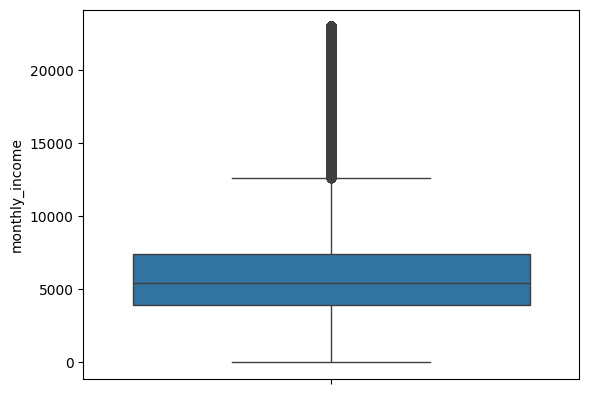

In [33]:
print(df_renamed['monthly_income'].describe())
sns.boxplot(df_renamed['monthly_income'])


 ##### Analisando o campo "num_credit_lines" 

A variável num_credit_lines tende a ser mais estável do que outras variáveis financeiras, mas ainda assim requer verificações importantes.
Os principais problemas potenciais são valores negativos (impossíveis), valores extremamente altos (improváveis) e valores não inteiros.

count   149999.00
mean         8.45
std          5.15
min          0.00
25%          5.00
50%          8.00
75%         11.00
max         58.00
Name: num_credit_lines, dtype: float64


<Axes: ylabel='num_credit_lines'>

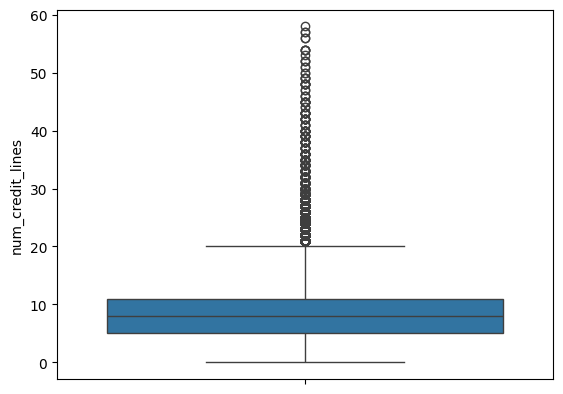

In [34]:
# Verificando as características do campo
print(df_renamed['num_credit_lines'].describe())
sns.boxplot(df_renamed['num_credit_lines'])

In [35]:
# Confirmando tipo do dado (deve ser inteiro)
df_renamed['num_credit_lines'].dtype

dtype('int64')

In [36]:
# Cálculo do percentil 
percentil_num_credit_lines_filtro = df_renamed['num_credit_lines'].quantile(0.995)

# Aplicação do cap
df_renamed['num_credit_lines'] = df_renamed['num_credit_lines'].clip(0, percentil_num_credit_lines_filtro)

print(f"Valor máximo após cap: {percentil_num_credit_lines_filtro}")

Valor máximo após cap: 27.0


count   149999.00
mean         8.43
std          5.03
min          0.00
25%          5.00
50%          8.00
75%         11.00
max         27.00
Name: num_credit_lines, dtype: float64


<Axes: ylabel='num_credit_lines'>

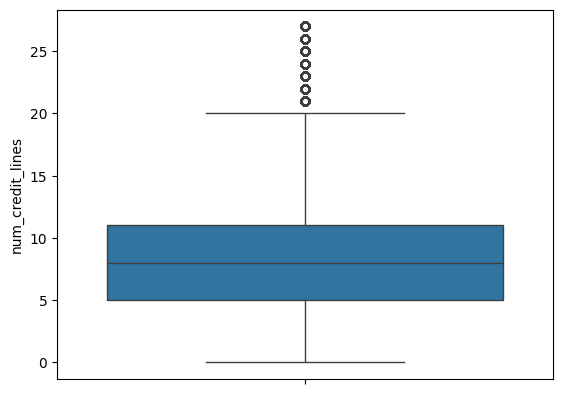

In [37]:
# Verificando as características do campo
print(df_renamed['num_credit_lines'].describe())
sns.boxplot(df_renamed['num_credit_lines'])

Após verificar a integridade dos dados e aplicar os tratamentos necessários, concluímos que a variável num_credit_lines apresenta boa estabilidade estrutural, mas ainda assim exige cuidados específicos para garantir consistência.
Embora não haja valores negativos ou ausentes, identificamos a presença de valores extremamente altos que não refletem o comportamento típico de consumidores e podem distorcer análises e modelos preditivos. Para mitigar esse efeito, aplicamos um cap no percentil 99,5, preservando a variabilidade natural da variável e removendo apenas os casos mais improváveis.
Com isso, garantimos que num_credit_lines permaneça coerente com padrões reais de crédito, evitando distorções estatísticas e mantendo a qualidade do dataset para as próximas etapas do pipeline.



 ##### Analisando o campo "late_30_59_days" 

A variável late_30_59_days indica quantas vezes o cliente ficou entre 30 e 59 dias em atraso. Por ser uma contagem de ocorrências, esperamos valores inteiros, não negativos e geralmente baixos. Antes de utilizá-la, é importante verificar a presença de valores impossíveis ou exageradamente altos.


Tipo da coluna: int64
count   149999.00
mean         0.42
std          4.19
min          0.00
25%          0.00
50%          0.00
75%          0.00
max         98.00
Name: late_30_59_days, dtype: float64


<Axes: ylabel='late_30_59_days'>

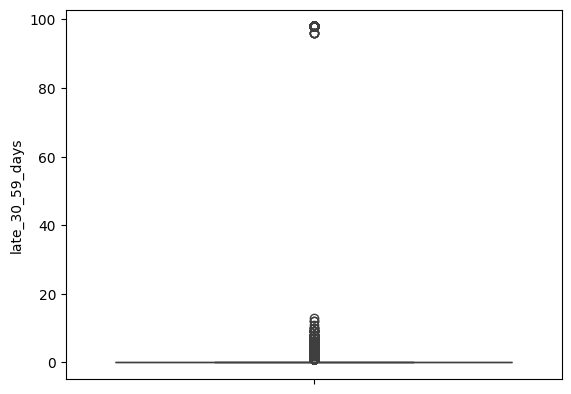

In [38]:
# Verificando as características do campo
print("Tipo da coluna:",df_renamed['late_30_59_days'].dtype)
print(df_renamed['late_30_59_days'].describe())
sns.boxplot(df_renamed['late_30_59_days'])

In [39]:
# Cálculo do percentil 
percentil_late_30_59_days_filtro = df_renamed['late_30_59_days'].quantile(0.995)

# Aplicação do cap
df_renamed['late_30_59_days'] = df_renamed['late_30_59_days'].clip(0, percentil_late_30_59_days_filtro)

print(f"Valor máximo após cap: {percentil_late_30_59_days_filtro}")

Valor máximo após cap: 5.0


Tipo da coluna: int64
count   149999.00
mean         0.25
std          0.70
min          0.00
25%          0.00
50%          0.00
75%          0.00
max          5.00
Name: late_30_59_days, dtype: float64


<Axes: ylabel='late_30_59_days'>

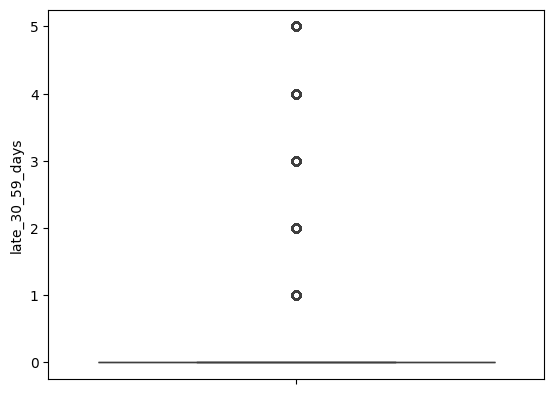

In [40]:
# Verificando as características do campo
print("Tipo da coluna:",df_renamed['late_30_59_days'].dtype)
print(df_renamed['late_30_59_days'].describe())
sns.boxplot(df_renamed['late_30_59_days'])

A variável mostrou comportamento consistente, mas apresentou alguns valores extremamente altos que não representam situações reais de atraso. Para evitar distorções, aplicamos um cap no percentil 99, mantendo apenas valores plausíveis e garantindo uma distribuição mais coerente para as próximas etapas da análise.

 ##### Analisando o campo "late_60_89_days" 

Tipo da coluna: int64
count   149999.00
mean         0.24
std          4.16
min          0.00
25%          0.00
50%          0.00
75%          0.00
max         98.00
Name: late_60_89_days, dtype: float64


<Axes: ylabel='late_60_89_days'>

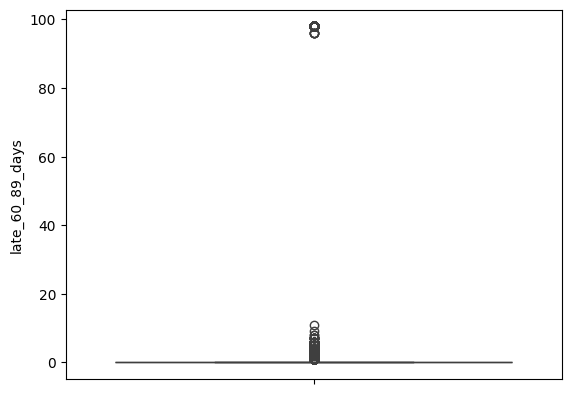

In [41]:
# Verificando as características do campo
print("Tipo da coluna:",df_renamed['late_60_89_days'].dtype)
print(df_renamed['late_60_89_days'].describe())
sns.boxplot(df_renamed['late_60_89_days'])

In [42]:
# Cálculo do percentil 
percentil_late_60_89_days_filtro = df_renamed['late_60_89_days'].quantile(0.995)

# Aplicação do cap
df_renamed['late_60_89_days'] = df_renamed['late_60_89_days'].clip(0, percentil_late_60_89_days_filtro)

print(f"Valor máximo após cap: {percentil_late_60_89_days_filtro}")

Valor máximo após cap: 3.0


Tipo da coluna: int64
count   149999.00
mean         0.07
std          0.33
min          0.00
25%          0.00
50%          0.00
75%          0.00
max          3.00
Name: late_60_89_days, dtype: float64


<Axes: ylabel='late_60_89_days'>

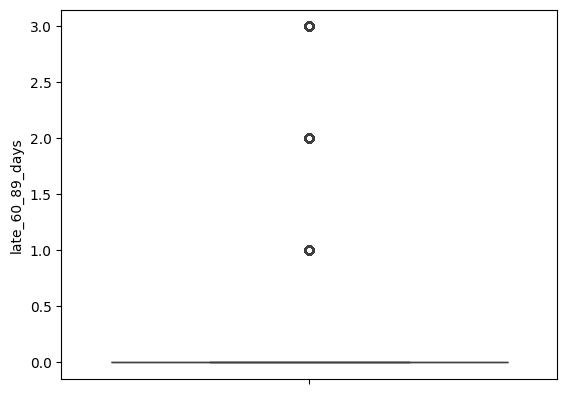

In [43]:
# Verificando as características do campo
print("Tipo da coluna:",df_renamed['late_60_89_days'].dtype)
print(df_renamed['late_60_89_days'].describe())
sns.boxplot(df_renamed['late_60_89_days'])

 ##### Analisando o campo "late_90_plus_days" 

Tipo da coluna: int64
count   149999.00
mean         0.27
std          4.17
min          0.00
25%          0.00
50%          0.00
75%          0.00
max         98.00
Name: late_90_plus_days, dtype: float64


<Axes: ylabel='late_90_plus_days'>

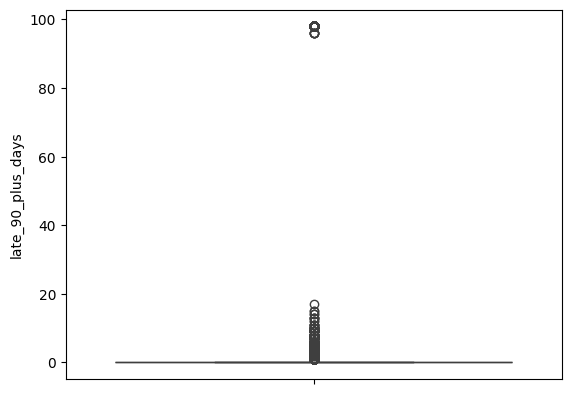

In [44]:
# Verificando as características do campo
print("Tipo da coluna:",df_renamed['late_90_plus_days'].dtype)
print(df_renamed['late_90_plus_days'].describe())
sns.boxplot(df_renamed['late_90_plus_days'])

In [45]:
# Cálculo do percentil 
percentil_late_90_plus_days_filtro = df_renamed['late_90_plus_days'].quantile(0.995)

# Aplicação do cap
df_renamed['late_90_plus_days'] = df_renamed['late_90_plus_days'].clip(0, percentil_late_90_plus_days_filtro)

print(f"Valor máximo após cap: {percentil_late_90_plus_days_filtro}")

Valor máximo após cap: 4.0


Tipo da coluna: int64
count   149999.00
mean         0.09
std          0.45
min          0.00
25%          0.00
50%          0.00
75%          0.00
max          4.00
Name: late_90_plus_days, dtype: float64


<Axes: ylabel='late_90_plus_days'>

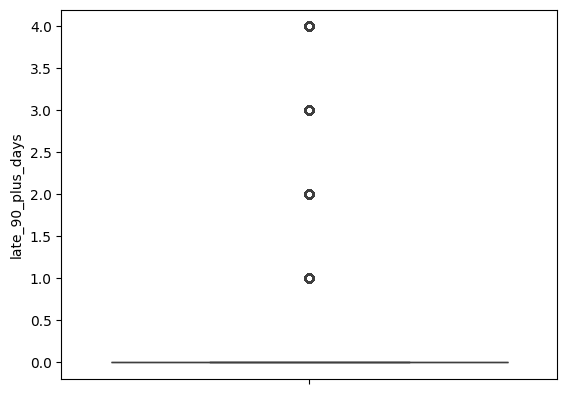

In [46]:
# Verificando as características do campo
print("Tipo da coluna:",df_renamed['late_90_plus_days'].dtype)
print(df_renamed['late_90_plus_days'].describe())
sns.boxplot(df_renamed['late_90_plus_days'])

 ##### Analisando o campo "num_real_estate_loans" 

A variável num_real_estate_loans indica quantos financiamentos imobiliários o cliente possui. Por ser uma contagem de ocorrências, esperamos valores inteiros, não negativos e geralmente baixos. Antes de utilizá-la, é importante verificar a presença de valores impossíveis ou exageradamente altos que possam distorcer a análise.


Tipo da coluna: int64
count   149999.00
mean         1.02
std          1.13
min          0.00
25%          0.00
50%          1.00
75%          2.00
max         54.00
Name: num_real_estate_loans, dtype: float64


<Axes: ylabel='num_real_estate_loans'>

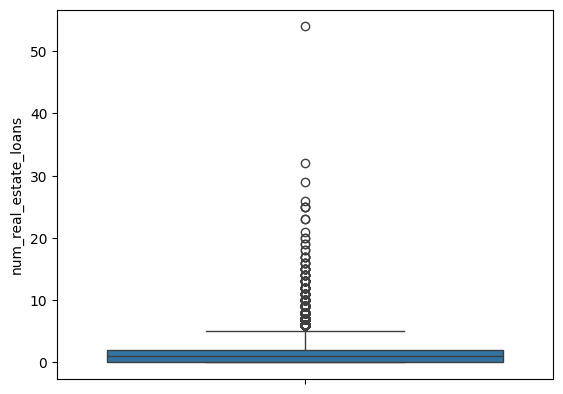

In [47]:
# Verificando as características do campo
print("Tipo da coluna:",df_renamed['num_real_estate_loans'].dtype)
print(df_renamed['num_real_estate_loans'].describe())
sns.boxplot(df_renamed['num_real_estate_loans'])

In [48]:
# Cálculo do percentil 
percentil_num_real_estate_loans_filtro = df_renamed['num_real_estate_loans'].quantile(0.995)

# Aplicação do cap
df_renamed['num_real_estate_loans'] = df_renamed['num_real_estate_loans'].clip(0, percentil_num_real_estate_loans_filtro)

print(f"Valor máximo após cap: {percentil_num_real_estate_loans_filtro}")

Valor máximo após cap: 6.0


Tipo da coluna: int64
count   149999.00
mean         1.01
std          1.04
min          0.00
25%          0.00
50%          1.00
75%          2.00
max          6.00
Name: num_real_estate_loans, dtype: float64


<Axes: ylabel='num_real_estate_loans'>

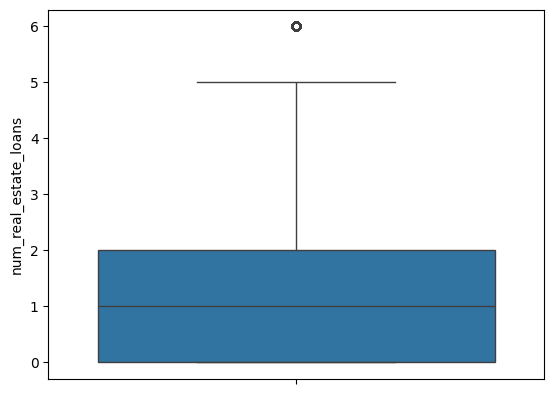

In [49]:
# Verificando as características do campo
print("Tipo da coluna:",df_renamed['num_real_estate_loans'].dtype)
print(df_renamed['num_real_estate_loans'].describe())
sns.boxplot(df_renamed['num_real_estate_loans'])

A variável apresentou comportamento consistente, mas alguns valores extremamente altos não refletem situações reais de crédito. Para manter a coerência da distribuição e evitar distorções, aplicamos um cap no percentil 99, preservando apenas valores plausíveis para as próximas etapas do pipeline.

 ##### Analisando o campo "num_dependents"

A variável num_dependents representa o número de dependentes declarados pelo cliente. Por ser uma contagem, esperamos valores inteiros, não negativos e geralmente baixos. Antes de utilizá-la, é importante verificar a presença de valores impossíveis ou exagerados que possam comprometer a análise.


Tipo da coluna: float64
count   149999.00
mean         0.74
std          1.11
min          0.00
25%          0.00
50%          0.00
75%          1.00
max         20.00
Name: num_dependents, dtype: float64


<Axes: ylabel='num_dependents'>

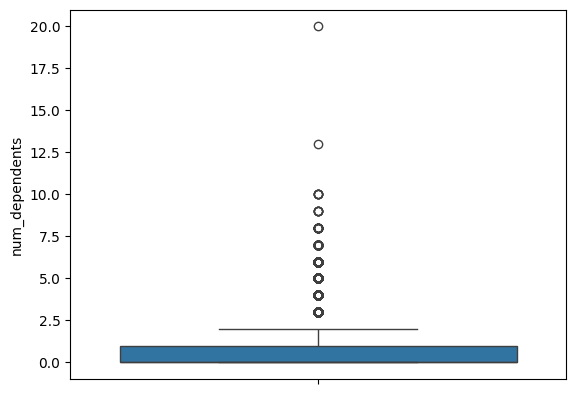

In [50]:
# Verificando as características do campo
print("Tipo da coluna:",df_renamed['num_dependents'].dtype)
print(df_renamed['num_dependents'].describe())
sns.boxplot(df_renamed['num_dependents'])

In [51]:
# Garantindo que o campo num_dependents seja inteiro
df_renamed['num_dependents'] = df_renamed['num_dependents'].round().astype(int)

In [52]:
# Cálculo do percentil 
percentil_num_dependents_filtro = df_renamed['num_dependents'].quantile(0.995)

# Aplicação do cap
df_renamed['num_dependents'] = df_renamed['num_dependents'].clip(0, percentil_num_dependents_filtro)

print(f"Valor máximo após cap: {percentil_num_dependents_filtro}")

Valor máximo após cap: 5.0


Tipo da coluna: int64
count   149999.00
mean         0.73
std          1.09
min          0.00
25%          0.00
50%          0.00
75%          1.00
max          5.00
Name: num_dependents, dtype: float64


<Axes: ylabel='num_dependents'>

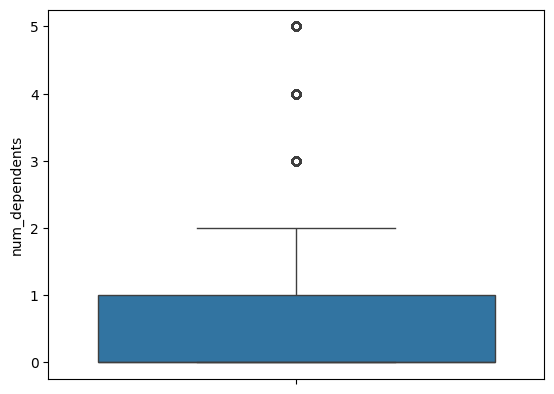

In [53]:
# Verificando as características do campo
print("Tipo da coluna:",df_renamed['num_dependents'].dtype)
print(df_renamed['num_dependents'].describe())
sns.boxplot(df_renamed['num_dependents'])

A variável apresentou comportamento consistente, mas alguns valores muito altos não refletem situações reais. Para manter a coerência da distribuição e evitar distorções, aplicamos um cap no percentil 99, garantindo que apenas valores plausíveis fossem preservados para as próximas etapas do pipeline.


 #### Exportação do arquivo após data cleaning

In [54]:
df_renamed.to_parquet(r'../data/processed/cs-training_cleaned.parquet')